<a href="https://colab.research.google.com/github/cesaraugustopereirabr/tcc-ciencia-dados-seletividade-penal/blob/main/Projeto_Pesquisa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Bloco 1 - Leitura robusta do CSV
# Jogar o arquivo CSV no file_path (arquivos)
file_path = "/content/sisdepen_1_17_csv.csv"

# !pip install chardet

import chardet, csv
import pandas as pd

# ler amostra para detecção de encoding
with open(file_path, "rb") as f:
    raw = f.read(200000)

det = chardet.detect(raw)
encodings_to_try = [det.get("encoding"), "utf-8", "latin-1", "cp1252", "iso-8859-1"]
encodings_to_try = [e for e in encodings_to_try if e]

df = None
last_err = None
for enc in encodings_to_try:
    try:
        # tentar detectar delimitador na amostra
        sample = raw.decode(enc, errors="replace")
        try:
            sniffer = csv.Sniffer()
            dialect = sniffer.sniff(sample[:10000])
            sep = dialect.delimiter
        except Exception:
            sep = ";"
        df = pd.read_csv(file_path, encoding=enc, sep=sep, low_memory=False)
        print(f"Arquivo lido com sucesso usando encoding={enc} e separador='{sep}'")
        break
    except Exception as e:
        last_err = e
        print(f"falha com encoding={enc}: {e}")
if df is None:
    raise RuntimeError("Não foi possível ler o arquivo. Último erro: " + repr(last_err))

# mostrar dimensões e primeiras colunas
print("Dimensões:", df.shape)
print("Colunas (exemplo):")
for c in df.columns[:40]:
    print(" -", c)

# salvar cópia limpa
df.to_csv("/content/cleaned_sisdepen_raw.csv", index=False)
print("Cópia salva em /content/cleaned_sisdepen_raw.csv")

Arquivo lido com sucesso usando encoding=ISO-8859-1 e separador=';'
Dimensões: (3130, 31)
Colunas (exemplo):
 - Ano
 - Referencia
 - UF
 - População prisional_total
 - Pessoas privadas de liberdade por faixa etaria_18 a 24 anos
 - pessoas privadas de liberdade por faixa etaria_25 a 29 anos
 - pessoas privadas de liberdade por faixa etaria_30 a 34 anos
 - pessoas privadas de liberdade por faixa etaria_35 a 45 anos
 - pessoas privadas de liberdade por faixa etaria_46 a 60 anos
 - pessoas privadas de liberdade por faixa etaria_61 a 70 anos
 - pessoas privadas de liberdade por faixa etaria_Mais de 70 anos
 - Pessoas privadas de liberdade por cor de pele_Branca
 - Pessoas privadas de liberdade por cor de pele_Preta
 - Pessoas privadas de liberdade por cor de pele_Parda
 - Pessoas privadas de liberdade por cor de pele_Amarela
 - Pessoas privadas de liberdade por cor de pele_Indigena
 - Crimes contra o patrimonio | Furto simples (Art. 155) | Total
 - Crimes contra o patrimonio | Furto qualifi

In [2]:
# Bloco 2 - Normalização mínima e identificação de colunas conhecidas
import re
import pandas as pd
import numpy as np

# carregar df
try:
    df
except NameError:
    df = pd.read_csv("/content/cleaned_sisdepen_raw.csv", low_memory=False)

# helper: busca coluna por termo (case-insensitive, substring)
def find_col(keyword, cols):
    keyword = keyword.lower()
    for c in cols:
        if keyword in str(c).lower():
            return c
    return None

cols = list(df.columns)

# colunas listadas
c_ano = find_col("ano", cols) or "Ano"
c_referencia = find_col("referencia", cols) or "Referencia"
c_uf = find_col("uf", cols) or "UF"
c_pop_total = find_col("população prisional_total", cols) or find_col("populacao prisional_total", cols) or find_col("população prisional", cols)

# colunas de faixa etária conforme listagem
age_keys = [
    "Pessoas privadas de liberdade por faixa etaria_18 a 24 anos",
    "pessoas privadas de liberdade por faixa etaria_25 a 29 anos",
    "pessoas privadas de liberdade por faixa etaria_30 a 34 anos",
    "pessoas privadas de liberdade por faixa etaria_35 a 45 anos",
    "pessoas privadas de liberdade por faixa etaria_46 a 60 anos",
    "pessoas privadas de liberdade por faixa etaria_61 a 70 anos",
    "pessoas privadas de liberdade por faixa etaria_Mais de 70 anos"
]
age_cols = []
for k in age_keys:
    found = find_col(k.split("_")[0], cols)  # procurar por padrão "Pessoas privadas de liberdade por faixa etaria"

    if k in cols:
        age_cols.append(k)
    else:
        # procurar colunas que contenham "faixa etaria" e os números da faixa
        for c in cols:
            low = c.lower()
            if "faixa etaria" in low or "faixa etária" in low or "18 a 24" in low or "25 a 29" in low or "30 a 34" in low or "35 a 45" in low or "46 a 60" in low or "61 a 70" in low or "mais de 70" in low:
                if c not in age_cols:
                    age_cols.append(c)

age_cols = list(dict.fromkeys(age_cols))

# colunas de cor/raça conforme listagem
race_keys = [
    "Pessoas privadas de liberdade por cor de pele_Branca",
    "Pessoas privadas de liberdade por cor de pele_Preta",
    "Pessoas privadas de liberdade por cor de pele_Parda",
    "Pessoas privadas de liberdade por cor de pele_Amarela",
    "Pessoas privadas de liberdade por cor de pele_Indigena"
]
race_cols = [c for c in cols if any(k.split("_")[-1].lower() in str(c).lower() for k in race_keys)]

if not race_cols:
    for c in cols:
        low = c.lower()
        if "cor de pele" in low or "por cor" in low or any(x in low for x in ["branca","preta","parda","amarela","indigena","indígena"]):
            race_cols.append(c)
race_cols = list(dict.fromkeys(race_cols))

# colunas de crimes (lista exata dos tipos penais (crimes) selecionados)
crime_cols_exact = [
    "Crimes contra o patrimonio | Furto simples (Art. 155) | Total",
    "Crimes contra o patrimonio | Furto qualificado",
    "Crimes contra o patrimonio | Roubo simples (Art. 157)",
    "Crimes contra o patrimonio | Roubo qualificado",
    "Crimes contra o patrimonio | Latrocinio",
    "Crimes contra o patrimonio | Extorsao",
    "Crimes contra o patrimonio | Extorsao mediante sequestro",
    "Crimes contra o patrimonio | Apropriacao indebita",
    "Crimes contra o patrimonio | Apropriacao indebita previdenciaria",
    "Crimes contra o patrimonio | Estelionato",
    "Crimes contra o patrimonio | Receptacao",
    "Crimes contra o patrimonio | Receptacao qualificada",
    "Trafico de drogas",
    "Associacao para o trafico",
    "Trafico internacional de drogas"
]
# mapear para colunas reais do df (case-insensitive substring match)
crime_cols = []
for name in crime_cols_exact:
    matched = None
    for c in cols:
        if name.lower() == str(c).lower() or name.lower() in str(c).lower() or str(c).lower() in name.lower():
            matched = c
            break
    if matched:
        crime_cols.append(matched)
# fallback: buscar por 'furto', 'roubo', 'estelionat', 'recepta', 'trafico' se algo faltar
if not crime_cols:
    for c in cols:
        lc = c.lower()
        if any(k in lc for k in ["furto", "roubo", "estelionat", "receptac", "trafic", "associacao para o trafico"]):
            crime_cols.append(c)
crime_cols = list(dict.fromkeys(crime_cols))

# report
print("Coluna Ano encontrada:", c_ano)
print("Coluna Referencia encontrada:", c_referencia)
print("Coluna UF encontrada:", c_uf)
print("Coluna População prisional encontrada:", c_pop_total)
print("\nColunas de faixa etária detectadas ({}):".format(len(age_cols)))
for c in age_cols: print(" -", c)
print("\nColunas de cor/raça detectadas ({}):".format(len(race_cols)))
for c in race_cols: print(" -", c)
print("\nColunas de crime detectadas ({}):".format(len(crime_cols)))
for c in crime_cols: print(" -", c)

# conversão: definir função para numerizar colunas que contêm números (limpar caracteres)
def numericize_series(s):
    return pd.to_numeric(
        s.astype(str).str.replace(r'[^\d\-,\.]', '', regex=True).str.replace(',', '.', regex=False).replace('', pd.NA),
        errors='coerce'
    )

# Converter pop total para num se existir
if c_pop_total in df.columns:
    df["_pop_total_num"] = numericize_series(df[c_pop_total])
else:
    df["_pop_total_num"] = pd.NA

# salvar versão identificada
df.to_csv("/content/cleaned_sisdepen_identified.csv", index=False)
print("Arquivo de identificação salvo em /content/cleaned_sisdepen_identified.csv")

Coluna Ano encontrada: Ano
Coluna Referencia encontrada: Referencia
Coluna UF encontrada: UF
Coluna População prisional encontrada: População prisional_total

Colunas de faixa etária detectadas (7):
 - Pessoas privadas de liberdade por faixa etaria_18 a 24 anos
 - pessoas privadas de liberdade por faixa etaria_25 a 29 anos
 - pessoas privadas de liberdade por faixa etaria_30 a 34 anos
 - pessoas privadas de liberdade por faixa etaria_35 a 45 anos
 - pessoas privadas de liberdade por faixa etaria_46 a 60 anos
 - pessoas privadas de liberdade por faixa etaria_61 a 70 anos
 - pessoas privadas de liberdade por faixa etaria_Mais de 70 anos

Colunas de cor/raça detectadas (5):
 - Pessoas privadas de liberdade por cor de pele_Branca
 - Pessoas privadas de liberdade por cor de pele_Preta
 - Pessoas privadas de liberdade por cor de pele_Parda
 - Pessoas privadas de liberdade por cor de pele_Amarela
 - Pessoas privadas de liberdade por cor de pele_Indigena

Colunas de crime detectadas (12):
 - C

In [3]:
# Bloco 3 - melt das colunas de crime para formato longo
import pandas as pd

# recarregar df caso necessário
try:
    df
except NameError:
    df = pd.read_csv("/content/cleaned_sisdepen_identified.csv", low_memory=False)

# id_vars: usar Ano, Referencia, UF e População prisional_total quando disponíveis
id_vars = []
for candidate in [c_ano, c_referencia, c_uf]:
    if candidate and candidate in df.columns:
        id_vars.append(candidate)
if "_pop_total_num" in df.columns:
    id_vars.append("_pop_total_num")

# garantir unicidade
id_vars = list(dict.fromkeys(id_vars))
print("id_vars usados no melt:", id_vars)

# garantir que crime_cols não esteja vazia
if not crime_cols:
    raise RuntimeError("Nenhuma coluna de crime detectada. Verifique os nomes e execute o Bloco 2 novamente.")

# efetuar melt
df_long = df.melt(id_vars=id_vars, value_vars=crime_cols, var_name="crime_raw", value_name="qtd_raw")

# numerizar qtd (quantidade)
df_long["qtd"] = numericize_series(df_long["qtd_raw"])

# extrair rótulo legível do crime (pegar parte mais significativa)
def rotulo_from_raw(x):
    s = str(x)
    parts = [p.strip() for p in s.split("|")]
    # se há 'Crimes contra o patrimonio | X | Total' pegar 'X'
    if len(parts) >= 3 and parts[-1].lower() == "total":
        return parts[-2]
    if len(parts) >= 2:
        return parts[-1]
    return s

df_long["crime_label"] = df_long["crime_raw"].apply(rotulo_from_raw).astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()

# categoria: se o raw contém 'traf' -> 'drogas' else 'patrimonio'
df_long["category"] = df_long["crime_raw"].astype(str).str.lower().apply(lambda s: "drogas" if "traf" in s or "droga" in s else "patrimonio")

# filtrar NAs e zeros
df_long = df_long[df_long["qtd"].notna() & (df_long["qtd"] > 0)].copy()

print("df_long criado com linhas:", len(df_long))
display(df_long.head(10))

# salvar
df_long.to_csv("/content/df_long_crimes.csv", index=False)
print("df_long salvo em /content/df_long_crimes.csv")

id_vars usados no melt: ['Ano', 'Referencia', 'UF', '_pop_total_num']
df_long criado com linhas: 17422


,Ano,Referencia,UF,_pop_total_num,crime_raw,qtd_raw,qtd,crime_label,category
4,2024,2024/2,AC,1670.0,Crimes contra o patrimonio | Furto simples (Ar...,70.0,70.0,Furto simples (Art. 155),patrimonio
5,2024,2024/2,AC,1724.0,Crimes contra o patrimonio | Furto simples (Ar...,31.0,31.0,Furto simples (Art. 155),patrimonio
8,2024,2024/2,AC,86.0,Crimes contra o patrimonio | Furto simples (Ar...,5.0,5.0,Furto simples (Art. 155),patrimonio
9,2024,2024/2,AC,25.0,Crimes contra o patrimonio | Furto simples (Ar...,3.0,3.0,Furto simples (Art. 155),patrimonio
10,2024,2024/2,AC,478.0,Crimes contra o patrimonio | Furto simples (Ar...,44.0,44.0,Furto simples (Art. 155),patrimonio
13,2024,2024/2,AC,480.0,Crimes contra o patrimonio | Furto simples (Ar...,6.0,6.0,Furto simples (Art. 155),patrimonio
18,2024,2024/2,AL,1670.0,Crimes contra o patrimonio | Furto simples (Ar...,20.0,20.0,Furto simples (Art. 155),patrimonio
20,2024,2024/2,AL,3183.0,Crimes contra o patrimonio | Furto simples (Ar...,61.0,61.0,Furto simples (Art. 155),patrimonio
21,2024,2024/2,AL,659.0,Crimes contra o patrimonio | Furto simples (Ar...,6.0,6.0,Furto simples (Art. 155),patrimonio
22,2024,2024/2,AL,148.0,Crimes contra o patrimonio | Furto simples (Ar...,2.0,2.0,Furto simples (Art. 155),patrimonio


df_long salvo em /content/df_long_crimes.csv


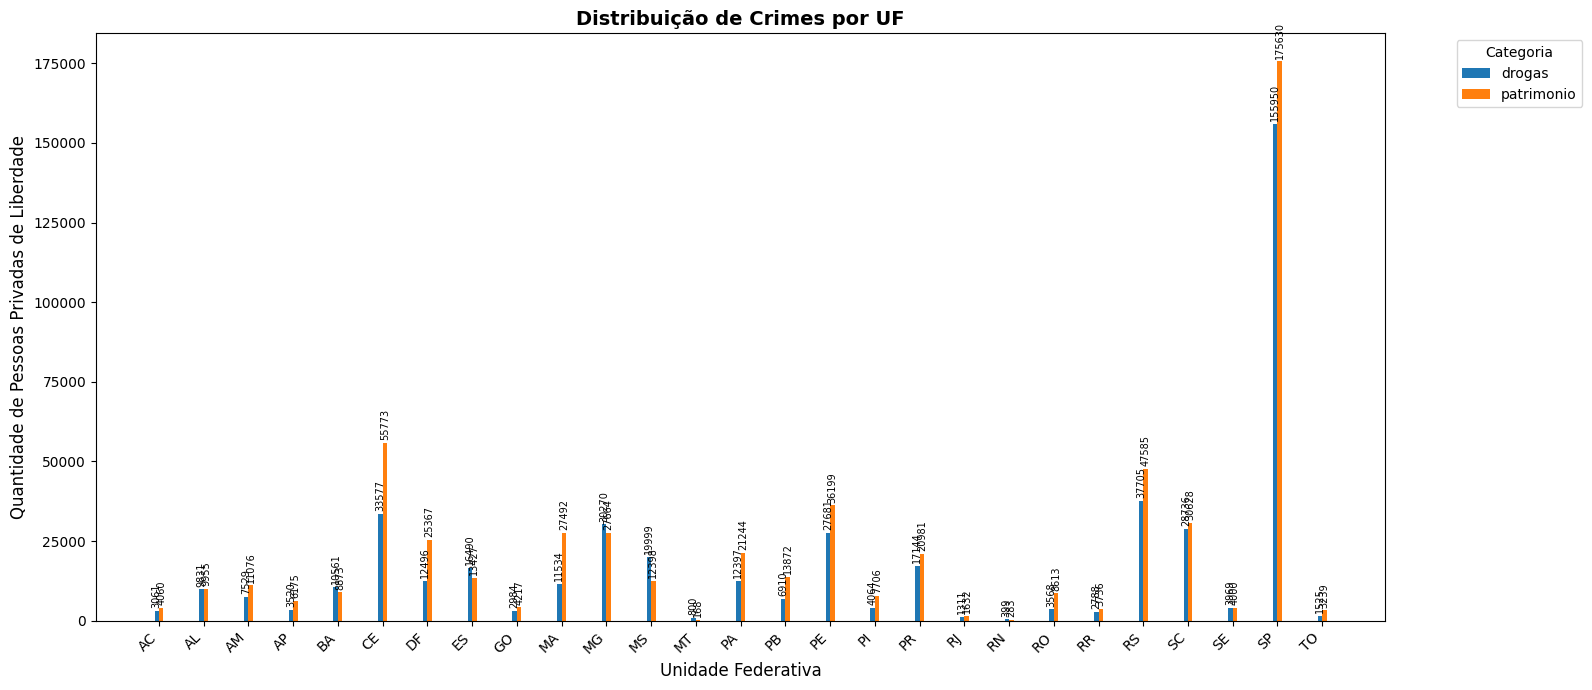

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Identifica coluna UF (estado da federação)
uf_col = "UF" if "UF" in df_long.columns else None

if uf_col:
    # 2. Agrupa dados
    agg_uf = df_long.groupby([uf_col, "category"])["qtd"].sum().unstack(fill_value=0).reset_index()

    # 3. Definições para plot
    categorias = [c for c in agg_uf.columns if c != uf_col]
    x = np.arange(len(agg_uf[uf_col]))  # posição dos estados
    largura = 0.1                       # largura das barras

    fig, ax = plt.subplots(figsize=(16, 7))

    # 4. Plota barras lado a lado
    for i, cat in enumerate(categorias):
        barras = ax.bar(x + i*largura, agg_uf[cat], width=largura, label=cat)
        # Adiciona labels (valores) em cima de cada barra
        ax.bar_label(barras, fmt="%.0f", fontsize=7, rotation=90, padding=2)

    # 5. Ajustes visuais
    ax.set_title("Distribuição de Crimes por UF", fontsize=14, weight="bold")
    ax.set_xlabel("Unidade Federativa", fontsize=12)
    ax.set_ylabel("Quantidade de Pessoas Privadas de Liberdade", fontsize=12)
    ax.set_xticks(x + largura * (len(categorias)-1) / 2)
    ax.set_xticklabels(agg_uf[uf_col], rotation=45, ha="right")
    ax.legend(title="Categoria", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

else:
    print("Coluna 'UF' não encontrada na base.")

Colunas de faixa etária a usar (7):
 - Pessoas privadas de liberdade por faixa etaria_18 a 24 anos
 - pessoas privadas de liberdade por faixa etaria_25 a 29 anos
 - pessoas privadas de liberdade por faixa etaria_30 a 34 anos
 - pessoas privadas de liberdade por faixa etaria_35 a 45 anos
 - pessoas privadas de liberdade por faixa etaria_46 a 60 anos
 - pessoas privadas de liberdade por faixa etaria_61 a 70 anos
 - pessoas privadas de liberdade por faixa etaria_Mais de 70 anos


,0
18 a 24 anos,260914
25 a 29 anos,354675
30 a 34 anos,313887
35 a 45 anos,431429
46 a 60 anos,181320
61 a 70 anos,32638
Mais de 70 anos,8305


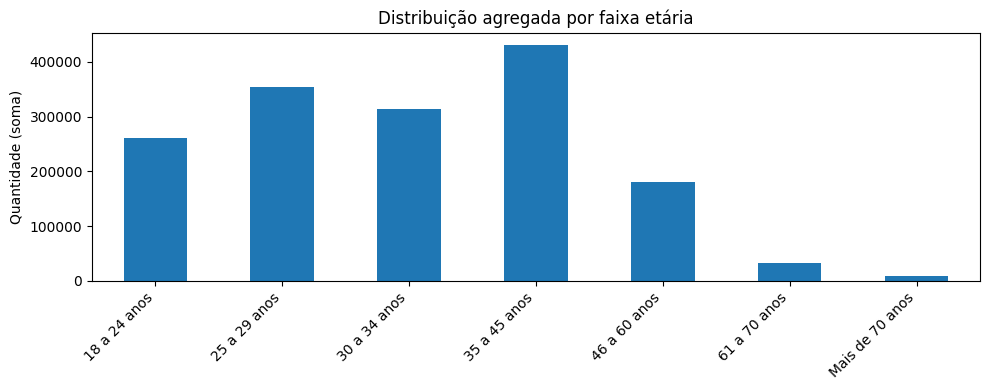

Resumo por faixa salvo em /content/age_summary.csv


In [5]:
# Bloco 5 - Distribuição agregada por faixa etária
import matplotlib.pyplot as plt
import pandas as pd

# garantir df original com colunas de faixa etária
try:
    df
except NameError:
    df = pd.read_csv("/content/cleaned_sisdepen_identified.csv", low_memory=False)

# age_cols já detectadas no Bloco 2; se não, detecta aqui
try:
    age_cols
except NameError:
    age_cols = [c for c in df.columns if any(p in c.lower() for p in ["faixa etaria","faixa etária","18 a 24","25 a 29","30 a 34","35 a 45","46 a 60","61 a 70","mais de 70"])]

print("Colunas de faixa etária a usar ({}):".format(len(age_cols)))
for c in age_cols: print(" -", c)

# somar cada coluna de faixa
age_summary = {}
for c in age_cols:
    s = numericize_series(df[c]) if c in df.columns else pd.Series(dtype=float)
    label = c.split("_")[-1] if "_" in c else c
    age_summary[label] = int(s.sum(skipna=True)) if not s.dropna().empty else 0

age_series = pd.Series(age_summary).sort_index()
display(age_series)

# gráfico
plt.figure(figsize=(10,4))
age_series.plot(kind="bar")
plt.title("Distribuição agregada por faixa etária")
plt.ylabel("Quantidade (soma)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# salvar
age_series.reset_index().rename(columns={"index":"faixa","0":"count"}).to_csv("/content/age_summary.csv", index=False)
print("Resumo por faixa salvo em /content/age_summary.csv")

Colunas de raça detectadas (5):
 - Pessoas privadas de liberdade por cor de pele_Branca
 - Pessoas privadas de liberdade por cor de pele_Preta
 - Pessoas privadas de liberdade por cor de pele_Parda
 - Pessoas privadas de liberdade por cor de pele_Amarela
 - Pessoas privadas de liberdade por cor de pele_Indigena


,0
Parda,793638
Branca,451064
Preta,243600
Amarela,15607
Indigena,3961


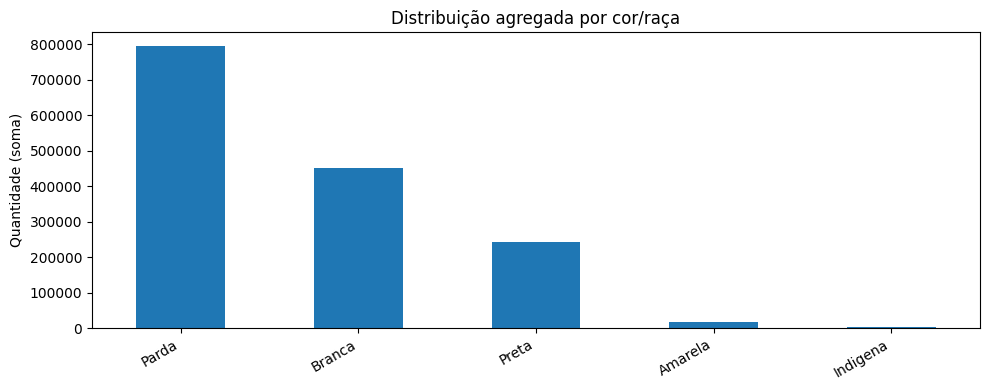

Resumo por cor/raça salvo em /content/race_summary.csv


In [6]:
# Bloco 6 - Distribuição agregada por cor/raça
import matplotlib.pyplot as plt
import pandas as pd

# garantir df
try:
    df
except NameError:
    df = pd.read_csv("/content/cleaned_sisdepen_identified.csv", low_memory=False)

# race_cols já detectadas; se não, detectar por palavras-chave
try:
    race_cols
except NameError:
    race_cols = [c for c in df.columns if any(k in c.lower() for k in ["por cor de pele","por cor","por raça","branca","preta","parda","amarela","indigena","indígena"])]

print("Colunas de raça detectadas ({}):".format(len(race_cols)))
for c in race_cols: print(" -", c)

race_summary = {}
for c in race_cols:
    s = numericize_series(df[c]) if c in df.columns else pd.Series(dtype=float)
    # rótulo legível: parte após '_' se existir, senão última parte após '|'
    if "_" in c:
        label = c.split("_")[-1]
    elif "|" in c:
        label = c.split("|")[-1].strip()
    else:
        label = c
    race_summary[label] = int(s.sum(skipna=True)) if not s.dropna().empty else 0

race_series = pd.Series(race_summary).sort_values(ascending=False)
display(race_series)

plt.figure(figsize=(10,4))
race_series.plot(kind="bar")
plt.title("Distribuição agregada por cor/raça")
plt.ylabel("Quantidade (soma)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# salvar
race_series.reset_index().rename(columns={"index":"categoria",0:"count"}).to_csv("/content/race_summary.csv", index=False)
print("Resumo por cor/raça salvo em /content/race_summary.csv")

In [7]:
# Bloco 7 - Cruzamento aproximado Crime x Raça por unidade territorial (Ano + UF)
import pandas as pd
import numpy as np

# carregar df e df_long
try:
    df
except NameError:
    df = pd.read_csv("/content/cleaned_sisdepen_identified.csv", low_memory=False)
try:
    df_long
except NameError:
    df_long = pd.read_csv("/content/df_long_crimes.csv", low_memory=False)

# definir unidade: Ano + UF (se existirem)
unit_cols = []
if c_ano in df.columns: unit_cols.append(c_ano)
if c_uf in df.columns: unit_cols.append(c_uf)
if not unit_cols:
    print("Ano e UF não detectados juntos — tentarei usar apenas UF.")
    if c_uf in df.columns:
        unit_cols = [c_uf]
    else:
        raise RuntimeError("Não foi possível identificar coluna de unidade para alocação (nem Ano nem UF).")

print("Usando unidade(es) para alocação:", unit_cols)

# preparar df_race_by_unit: agregação por unit_cols com as colunas de raça
race_unit = df.groupby(unit_cols)[race_cols].sum().reset_index()
# sum numericize to be safe
for c in race_cols:
    race_unit[c] = numericize_series(race_unit[c]).fillna(0)

# proporções por unidade
race_unit["race_total_unit"] = race_unit[race_cols].sum(axis=1)
for c in race_cols:
    race_unit[c + "_prop"] = np.where(race_unit["race_total_unit"] > 0, race_unit[c] / race_unit["race_total_unit"], 0)

# preparar df_crime_by_unit: pegar df_long e agregar qtd por unit_cols + crime_label
group_cols = unit_cols + ["crime_label"]
crime_unit = df_long.groupby(group_cols)["qtd"].sum().reset_index()

# unir proporções de raça
merged = crime_unit.merge(race_unit, on=unit_cols, how="left", suffixes=("","_race"))

# alocar: para cada raça, criar coluna alocada = qtd * prop
alloc_rows = []
for rc in race_cols:
    prop_col = rc + "_prop"
    if prop_col in merged.columns:
        merged["allocated_" + rc] = merged["qtd"] * merged[prop_col]
    else:
        merged["allocated_" + rc] = 0.0

# agregar alocações por crime_label e raça (soma nacional/por unidade)
alloc_cols = ["allocated_" + rc for rc in race_cols]
alloc_by_crime = merged.groupby("crime_label")[alloc_cols].sum().reset_index()

# limpar nomes das colunas para rótulos legíveis
rename_map = {}
for rc in race_cols:
    lbl = rc.split("_")[-1] if "_" in rc else rc
    rename_map["allocated_" + rc] = lbl

alloc_by_crime = alloc_by_crime.rename(columns=rename_map)
display(alloc_by_crime.head(30))

# salvar
alloc_by_crime.to_csv("/content/approx_crime_by_race_allocated.csv", index=False)
print("Cruzamento aproximado salvo em /content/approx_crime_by_race_allocated.csv")

Usando unidade(es) para alocação: ['Ano', 'UF']


,crime_label,Branca,Preta,Parda,Amarela,Indigena
0,Apropriacao indebita,752.728793,291.671412,1061.808015,29.317947,5.473833
1,Associacao para o trafico,19908.986273,8369.479702,30268.092041,571.224032,197.217952
2,Estelionato,2545.907797,1248.259924,4492.652019,96.454202,19.726058
3,Extorsao,2494.238791,1083.492455,3661.038577,85.631230,16.598947
4,Furto qualificado,22636.630185,10181.835624,35249.826884,792.285078,207.422229
5,Furto simples (Art. 155),23884.156298,11465.815180,40176.284967,922.133294,208.610261
6,Latrocinio,9496.449393,4544.993108,16670.141954,348.094364,89.321181
7,Receptacao,11463.072016,5594.163113,21199.496554,367.108117,106.160201
8,Roubo qualificado,65417.323831,33849.109628,124541.056317,2323.656484,591.853740
9,Roubo simples (Art. 157),36399.982395,18384.224804,65293.066891,1428.523667,275.202244


Cruzamento aproximado salvo em /content/approx_crime_by_race_allocated.csv


In [8]:
#Bloco8
# ===============================================================
# Estimativa indireta da população prisional por crimes tributários
# Autor: Cesar Augusto Pereira
# Fonte dos dados: Relatório SENAPPEN 2024
# ===============================================================

# População prisional total (dado oficial SENAPPEN 2024)
pop_total = 909067

# O relatório informa que "outros crimes" representam MENOS DE 1% do total.
# Como não há detalhamento específico para crimes tributários,
# usaremos esse valor máximo (1%) como limite superior.
percentual_outros = 0.01  # 1%

# Estimativa máxima possível de presos por crimes tributários
# (hipótese de que TODO o 1% correspondesse a crimes tributários)
estimativa_max = pop_total * percentual_outros

# Para tornar a análise mais realista, consideramos uma estimativa conservadora.
# Suponhamos que apenas 20% do 1% (isto é, 0,2% do total) sejam de crimes tributários,
# e os outros 80% de outros tipos penais residuais.
proporcao_tributarios = 0.2
estimativa_min = estimativa_max * proporcao_tributarios

# Exibindo os resultados
print("População prisional total:", pop_total)
print("Estimativa máxima (1% do total):", round(estimativa_max))
print("Estimativa conservadora (20% do 1%):", round(estimativa_min))

# ===============================================================
# Interpretação dos resultados:
# - O valor máximo possível seria de aproximadamente 9.091 presos.
# - De forma conservadora, poderíamos estimar em torno de 1.800 presos.
# - Comparação: apenas o crime de furto sozinho responde por mais de 66 mil presos,
#   ou seja, cerca de 10 vezes mais do que a hipótese máxima dos crimes tributários.
# ===============================================================

População prisional total: 909067
Estimativa máxima (1% do total): 9091
Estimativa conservadora (20% do 1%): 1818


In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Dados principais (SENAPPEN 2024)
pop_total = 909067
dados = {
    "População prisional total": pop_total,
    "Crimes contra o patrimônio": 0.383 * pop_total,   # 38,3%
    "Furto": 0.073 * pop_total,                        # 7,3%
    "Crimes tributários (estimativa máxima)": 0.01 * pop_total,   # até 1%
    "Crimes tributários (estimativa conservadora)": 0.002 * pop_total  # 0,2%
}

# Convertendo em DataFrame para facilitar gráficos
df = pd.DataFrame.from_dict(dados, orient="index", columns=["Quantidade"])
df

,Quantidade
População prisional total,909067.000
Crimes contra o patrimônio,348172.661
Furto,66361.891
Crimes tributários (estimativa máxima),9090.670
Crimes tributários (estimativa conservadora),1818.134


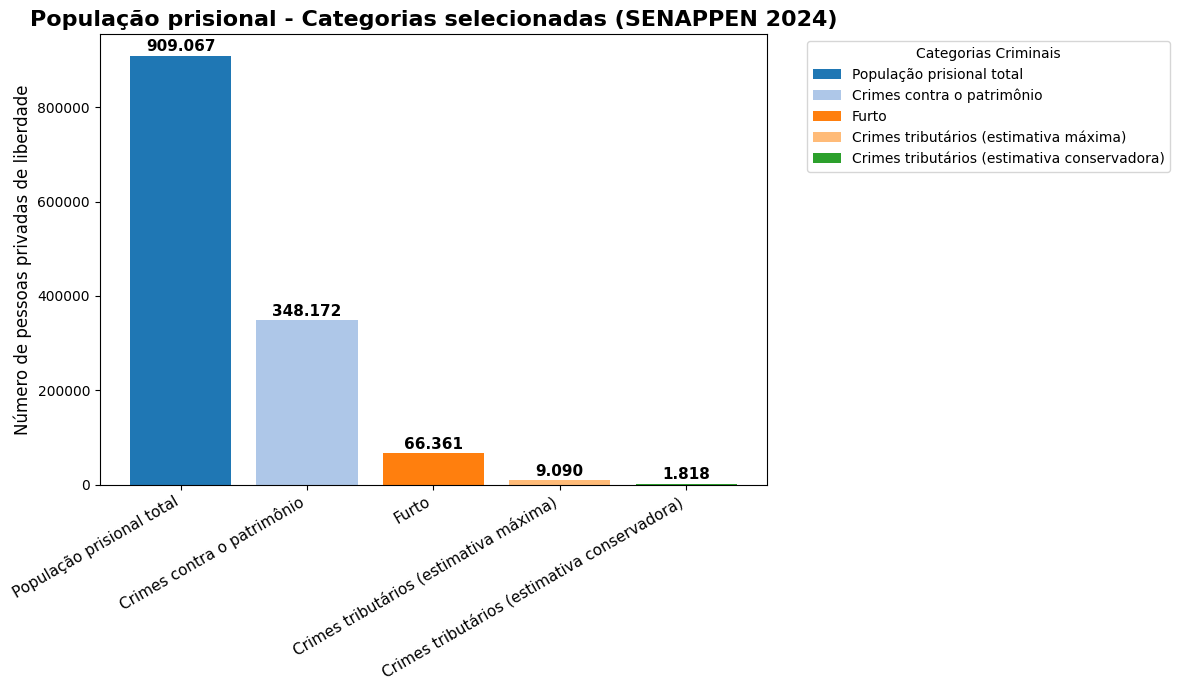

In [10]:
# ===============================================================
# Gráfico comparativo entre categorias criminais selecionadas
# ===============================================================

import matplotlib.pyplot as plt

# Criando o gráfico de barras com cores distintas
plt.figure(figsize=(12,7))
bars = plt.bar(df.index, df["Quantidade"], color=plt.cm.tab20.colors)

# Título e eixos
plt.title("População prisional - Categorias selecionadas (SENAPPEN 2024)", fontsize=16, fontweight="bold")
plt.ylabel("Número de pessoas privadas de liberdade", fontsize=12)
plt.xticks(rotation=30, ha="right", fontsize=11)

# Adiciona os valores acima das barras
for i, v in enumerate(df["Quantidade"]):
    plt.text(i, v + (max(df["Quantidade"])*0.01), f"{int(v):,}".replace(",", "."),
             ha="center", fontsize=11, fontweight="bold", color="black")

# Criação da legenda com nomes das categorias
plt.legend(bars, df.index, title="Categorias Criminais", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10)

# Layout ajustado para não cortar legenda
plt.tight_layout()

plt.show()

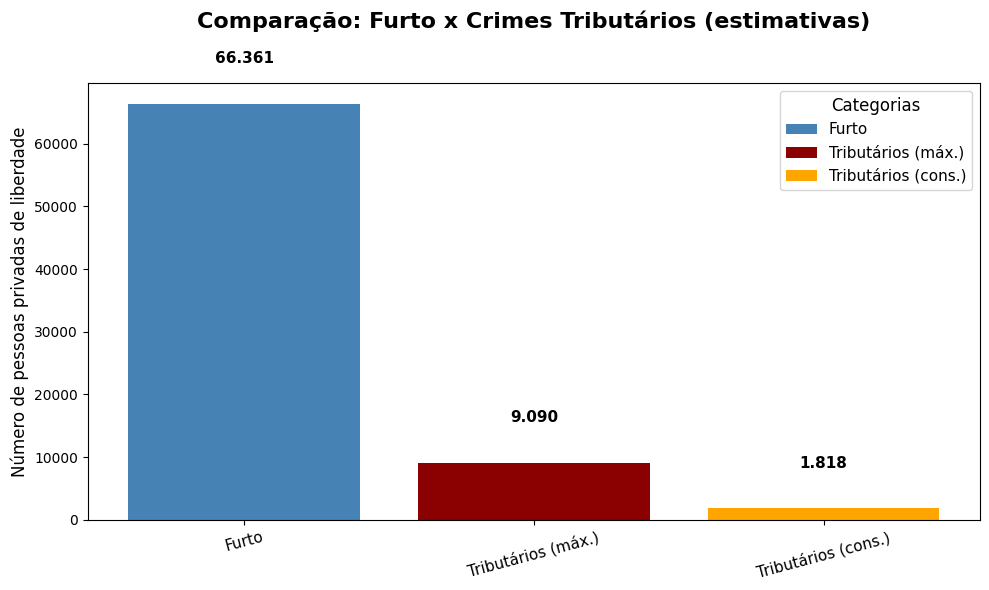

In [11]:
# ===============================================================
# Comparação direta: Furto x Crimes Tributários
# ===============================================================

comparacao = {
    "Furto": dados["Furto"],
    "Tributários (máx.)": dados["Crimes tributários (estimativa máxima)"],
    "Tributários (cons.)": dados["Crimes tributários (estimativa conservadora)"]
}

df_comp = pd.DataFrame.from_dict(comparacao, orient="index", columns=["Quantidade"])

# Definindo cores personalizadas
cores = ["steelblue", "darkred", "orange"]

plt.figure(figsize=(10,6))
barras = plt.bar(df_comp.index, df_comp["Quantidade"], color=cores)

# Título e eixos (com mais espaço do topo para evitar sobreposição)
plt.title("Comparação: Furto x Crimes Tributários (estimativas)",
          fontsize=16, weight="bold", pad=40)

plt.ylabel("Número de pessoas privadas de liberdade", fontsize=12)
plt.xticks(rotation=15, ha="center", fontsize=11)

# Adiciona os valores acima das barras (com espaçamento maior)
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura + 6000,
             f"{int(altura):,}".replace(",", "."),
             ha="center", va="bottom", fontsize=11, weight="bold")

# Legenda
plt.legend(barras, df_comp.index, title="Categorias", fontsize=11,
           title_fontsize=12, loc="upper right")

plt.tight_layout()
plt.show()

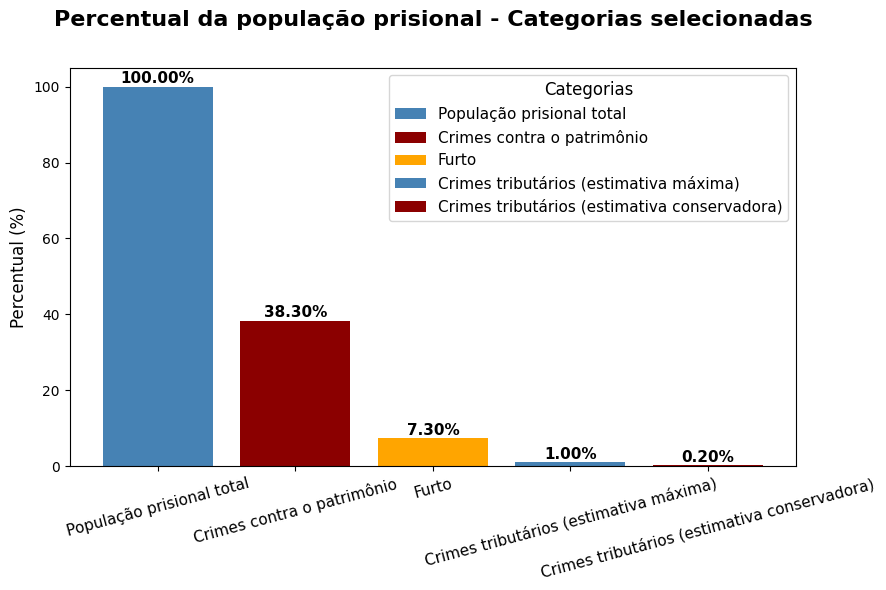

In [12]:
# ===============================================================
# Distribuição percentual das categorias em relação ao total
# ===============================================================

df_percentual = (df / pop_total) * 100

plt.figure(figsize=(9,6))

# Definindo cores personalizadas para destacar bem
cores = ["steelblue", "darkred", "orange"]
barras = plt.bar(df_percentual.index, df_percentual["Quantidade"], color=cores)

# Título afastado
plt.title("Percentual da população prisional - Categorias selecionadas",
          fontsize=16, weight="bold", pad=30)

plt.ylabel("Percentual (%)", fontsize=12)
plt.xticks(rotation=15, ha="center", fontsize=11)

# Adiciona os valores acima das barras (com pequeno espaçamento)
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, altura + 0.15,
             f"{altura:.2f}%", ha="center", va="bottom", fontsize=11, weight="bold")

# Legenda clara
plt.legend(barras, df_percentual.index, title="Categorias", fontsize=11,
           title_fontsize=12, loc="upper right")

plt.tight_layout()
plt.show()

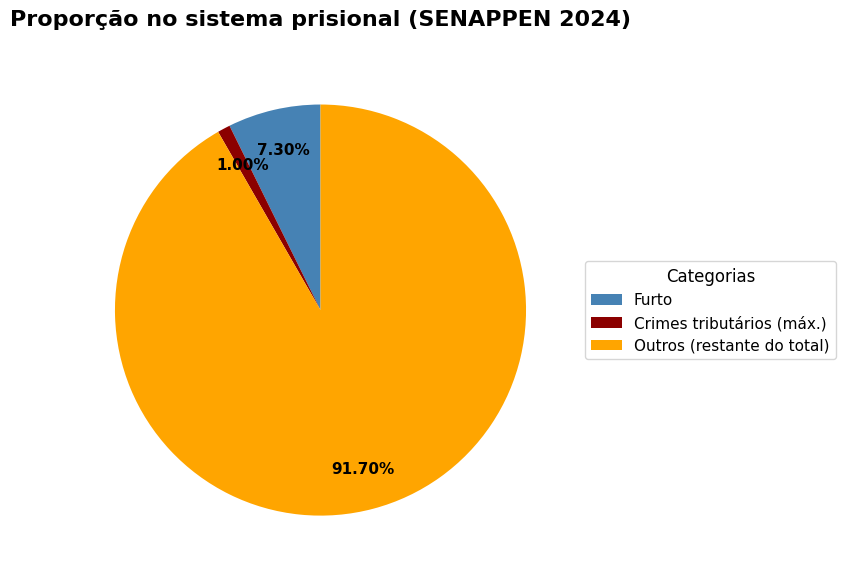

In [13]:
# ===============================================================
# Gráfico de pizza - proporção Furto vs Tributários vs Outros
# ===============================================================

pizza = {
    "Furto": dados["Furto"],
    "Crimes tributários (máx.)": dados["Crimes tributários (estimativa máxima)"],
    "Outros (restante do total)": pop_total - (dados["Furto"] + dados["Crimes tributários (estimativa máxima)"])
}

# Cores personalizadas
cores = ["steelblue", "darkred", "orange"]

plt.figure(figsize=(8,8))

# Gera o gráfico de pizza
fatias, textos, autotextos = plt.pie(
    pizza.values(),
    labels=None,  # remove labels diretas
    autopct="%.2f%%",
    startangle=90,
    colors=cores,
    pctdistance=0.8  # aproxima os percentuais do centro
)

# Ajusta estilo dos percentuais
for autotext in autotextos:
    autotext.set_fontsize(11)
    autotext.set_weight("bold")

# Título mais destacado
plt.title("Proporção no sistema prisional (SENAPPEN 2024)",
          fontsize=16, weight="bold", pad=20)

# Legenda externa
plt.legend(
    pizza.keys(),
    title="Categorias",
    fontsize=11,
    title_fontsize=12,
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()
plt.show()